In [1]:
import pandas as pd

def read_csv_to_dataframe(file_path: str) -> pd.DataFrame:
    try:
        df = pd.read_csv(file_path)
        return df
    except Exception as e:
        print(f"Error reading CSV file: {e}")
        return pd.DataFrame()

In [2]:
Rosedata_df = read_csv_to_dataframe("Event_core_v4.csv")
print(Rosedata_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46 entries, 0 to 45
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   event_date                    29 non-null     object 
 1   event_id                      29 non-null     object 
 2   parent_event_id               46 non-null     object 
 3   type                          46 non-null     object 
 4   location_id                   46 non-null     object 
 5   decimal_latitud               29 non-null     float64
 6   decimal_longitude             29 non-null     float64
 7   depth_m                       46 non-null     int64  
 8   habitat                       46 non-null     object 
 9   conteo_ind                    46 non-null     int64  
 10  temperat_grad_c               46 non-null     float64
 11  total_organic_matter_percent  46 non-null     float64
 12  proport_silt_clay_percent     46 non-null     int64  
 13  prop_si

In [4]:
# Select the columns we want to use
temp_tom_siltclay_df = Rosedata_df[['temperat_grad_c', 'total_organic_matter_percent', 'proport_silt_clay_percent']]

# Print df head to check
print(temp_tom_siltclay_df.head())

   temperat_grad_c  total_organic_matter_percent  proport_silt_clay_percent
0             28.1                           8.2                         56
1             28.1                           8.2                         56
2             28.1                           8.2                         56
3             28.1                           8.5                          8
4             28.0                           9.6                         13


In [5]:
#Calculate the Spearman correlation matrix
corr_matrix = temp_tom_siltclay_df.corr(method='spearman')

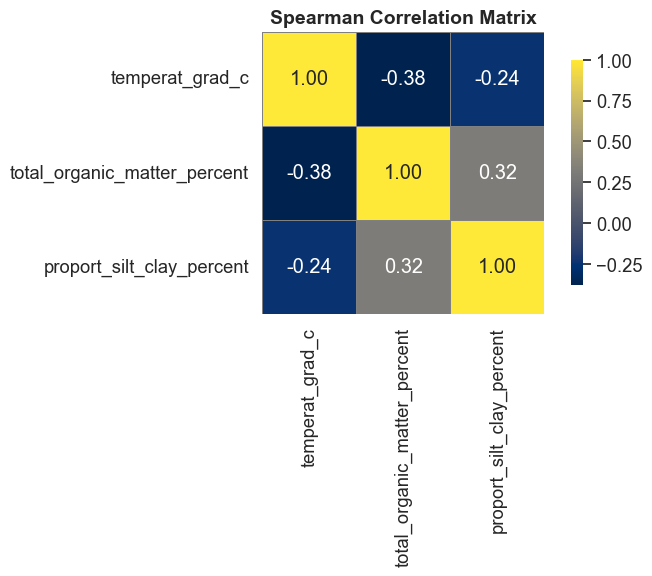

In [6]:
# Plot the Spearman correlation matrix

import matplotlib.pyplot as plt
import seaborn as sns

# Plot the heatmap 
plt.figure(figsize=(8, 6))
sns.set(style="white", font_scale=1.2)
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt=".2f", 
            cmap='cividis', 
            square=True, 
            linewidths=0.5, 
            linecolor='gray',
            cbar_kws={'shrink': 0.8})

plt.title('Spearman Correlation Matrix', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()